# Projeto: Análise de Exploratória do Titanic
## Projeto - Python | bytes4futures
### Autores: Isabelle Euclides & Shaini Dittberner

---
Este projeto visa analisar os fatores que influenciaram a sobrevivência dos passageiros do Titanic, utilizando técnicas de estatística descritiva e visualização de dados.

### 1. Configuração do Ambiente e Dados
Nesta etapa, carregamos as ferramentas necessárias e o conjunto de dados original.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

### 2. Carga e Exploração Inicial
Importação do dataset e visualização das primeiras linhas para entender a estrutura dos dados.

In [21]:
# Importando o arquivo csv
df = pd.read_csv('titanic_train.csv')

# Visualizando as primeiras 5 linhas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Limpeza de Dados e Feature Engineering
Preparação do dataset para a análise estatística, removendo ruídos e convertendo variáveis categóricas.

#### 3.1 Tratamento de Idades Ausentes
Em vez de usar uma média global, optamos por uma abordagem mais precisa: calcular a média de idade separada por gênero e preencher as lacunas correspondentes.

In [22]:
# Cálculo da média de idade por gênero
mean_male = df[df['Sex'] == 'male']['Age'].mean()
mean_female = df[df['Sex'] == 'female']['Age'].mean()

# Preenchimento dos valores nulos (Imputação Condicional)
df.loc[(df['Sex'] == 'female') & (df['Age'].isnull()), 'Age'] = mean_female
df.loc[(df['Sex'] == 'male') & (df['Age'].isnull()), 'Age'] = mean_male

#### 3.2 Tratamento da Coluna 'Embarked'
Para a porta de embarque, utilizamos a Moda (o valor que mais se repete), que é a técnica padrão para variáveis categóricas com poucos dados faltantes.

In [24]:
# Identificando o valor mais frequente (Moda)
embarked_mode = df['Embarked'].mode()[0]

# Preenchendo os valores nulos
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

#### 3.3 Remoção de Colunas e Codificação
Nesta fase, descartamos dados que não auxiliam na predição de sobrevivência e transformamos variáveis categóricas em numéricas para permitir cálculos de correlação.

In [25]:
# Passo 1: Remoção de colunas irrelevantes
# - 'Cabin': Excesso de valores ausentes (NaN).
# - 'Ticket': Identificador sem impacto direto na sobrevivência.
df.drop(columns=['Cabin', 'Ticket'], inplace=True)

# Passo 2: Feature Engineering (Conversão de Gênero)
# Criamos 'Is_Female' onde 1 = Feminino e 0 = Masculino
df['Is_Female'] = df['Sex'].map({'female': 1, 'male': 0})

### 4. Análise Geral de Gênero
Nesta seção, investigamos a hipótese "Mulheres e crianças primeiro" analisando a distribuição total de passageiros e o contraste real entre sobreviventes e não sobreviventes por gênero.

#### 4.1 Processamento e Agrupamento de Dados
Antes da visualização, consolidamos os números absolutos para entender o volume de passageiros masculinos e femininos.

In [28]:
# Contagem total de passageiros por gênero
passengers_by_gender = df.groupby("Sex").size()

# Cruzamento de dados: Sobrevivência x Gênero
# Unstack transforma o agrupamento em uma tabela comparativa (matriz)
sobrevivencia_genero = df.groupby(['Sex', 'Survived']).size().unstack()

# Exibição da tabela de resumo
sobrevivencia_genero

Survived,0,1
Sex,,
female,81,233
male,468,109


#### 4.2 Visualização Comparativa (Sobreviventes vs. Não Sobreviventes)
Utilizamos um gráfico de barras agrupadas para evidenciar a disparidade de sobrevivência. O uso de colunas lado a lado permite observar que, embora houvesse mais homens a bordo, a quantidade de sobreviventes femininas foi drasticamente superior.

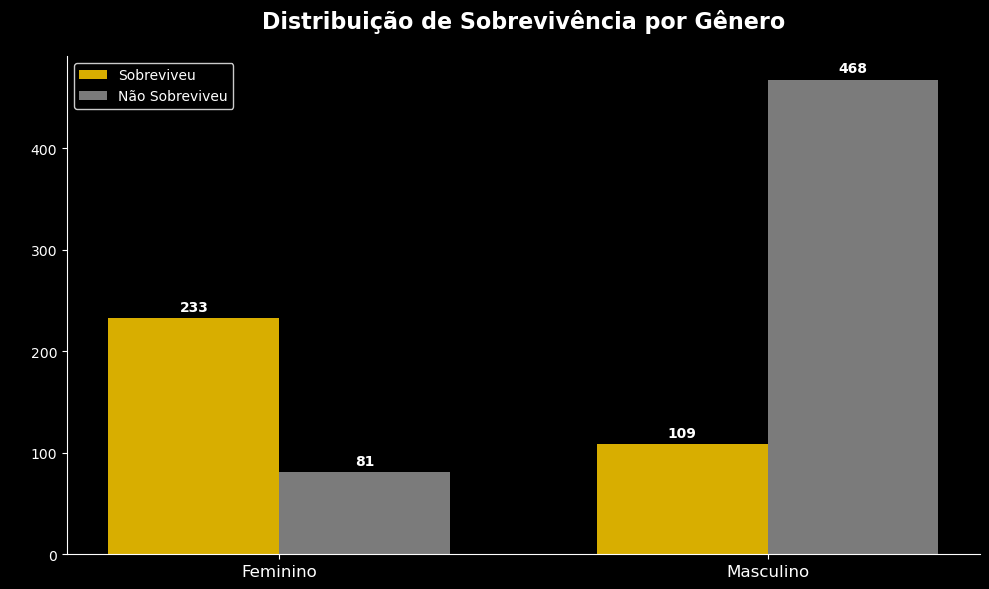

In [29]:
# 1. Preparação dos arrays para o gráfico
labels = ['Feminino', 'Masculino']
sobreviveu = [sobrevivencia_genero.loc['female', 1], sobrevivencia_genero.loc['male', 1]]
nao_sobreviveu = [sobrevivencia_genero.loc['female', 0], sobrevivencia_genero.loc['male', 0]]

x = np.arange(len(labels))  # Localização dos grupos no eixo X
width = 0.35              # Largura das barras individuais

# 2. Configuração de Estilo "Dark Mode"
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'

fig, ax = plt.subplots(figsize=(10, 6))

# Criando as barras agrupadas
# Deslocamos cada barra metade da largura para esquerda/direita para não sobrepor
rects1 = ax.bar(x - width/2, sobreviveu, width, label='Sobreviveu', color='#d8ae00') # Dourado
rects2 = ax.bar(x + width/2, nao_sobreviveu, width, label='Não Sobreviveu', color='#7b7b7b') # Cinza

# 3. Customização de Títulos e Eixos
ax.set_title('Distribuição de Sobrevivência por Gênero', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Quantidade de Passageiros', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(facecolor='black', edgecolor='white')

# Função auxiliar para adicionar rótulos de dados (números exatos) sobre as barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3 pontos acima da barra
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Ajustes Estéticos (Limpeza visual das bordas)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

### 5. Análise de Correlação (Matriz de Calor)
Nesta etapa, aplicamos a correlação de Pearson para quantificar a força da relação entre as variáveis numéricas e a sobrevivência. O objetivo é identificar quais fatores foram os principais preditores de quem sobreviveu ao desastre.

#### 5.1 Seleção de Variáveis Relevantes
Para que a matriz seja clara e útil, selecionamos apenas as colunas que possuem significado estatístico direto, excluindo identificadores únicos e variáveis já tratadas na limpeza de dados.

In [31]:
# Selecionando colunas numéricas de interesse
# 'Is_Female' é incluída para medir o impacto do gênero matematicamente
colunas_analise = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Is_Female']

# Calculando a matriz de correlação (Pearson por padrão)
corr_mtx = df[colunas_analise].corr()

### 5.2 Visualização com Heatmap
Utilizamos a biblioteca Seaborn para gerar um mapa de calor. A escala de cores permite identificar rapidamente correlações positivas (Azul) e negativas (Vermelho).

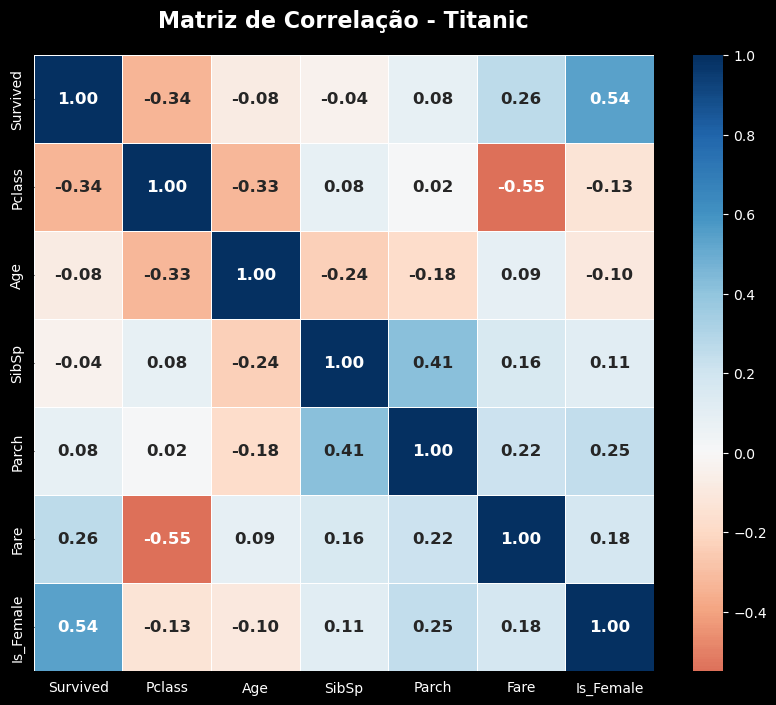

In [32]:
# Configuração do tamanho e estilo do gráfico
plt.figure(figsize=(10, 8))
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'

# Gerando o Heatmap
sns.heatmap(corr_mtx, 
            annot=True,      # Exibe os coeficientes em cada célula
            fmt=".2f",       # Formata para duas casas decimais
            cmap='RdBu',     # Divergente: Vermelho (Negativo) -> Branco -> Azul (Positivo)
            center=0,        # Define o ponto neutro da cor
            linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"})

# Customização Visual (Alinhada ao padrão Dark Mode do projeto)
plt.title('Matriz de Correlação - Titanic', fontsize=16, fontweight='bold', color='white', pad=20)
plt.xticks(color='white')
plt.yticks(color='white')

# Ajuste técnico para garantir que a barra lateral de cores tenha texto visível
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

### 6. Aprofundamento: Análise por Faixa Etária
Nesta etapa, investigamos se a idade do passageiro afeta diretamente a probabilidade de sobrevivência e como as correlações entre variáveis mudam em diferentes fases da vida.

#### 6.1 Distribuição de Densidade (KDE)
Utilizamos um gráfico de densidade para visualizar em quais faixas etárias houve maior concentração de sobreviventes.

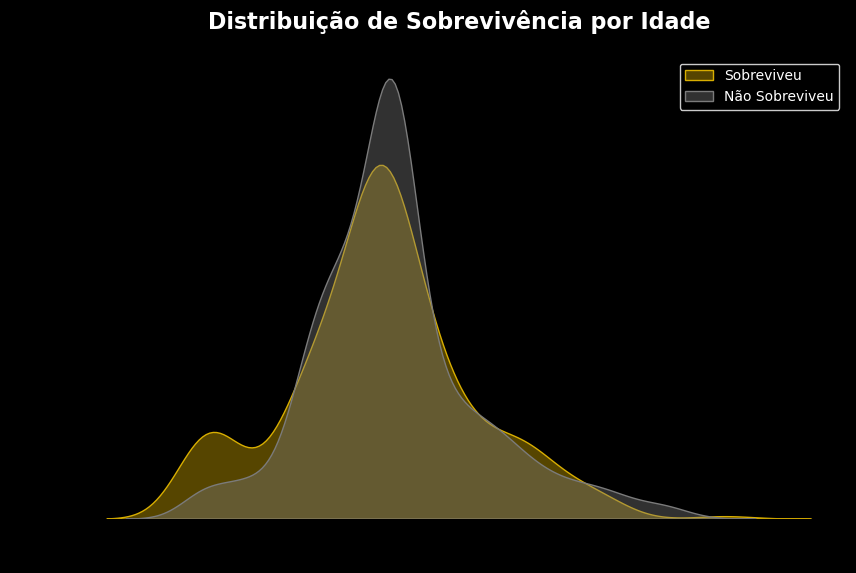

In [33]:
# 1. Configuração de Estilo (Fundo preto e letras brancas)
plt.rcParams.update({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'text.color': 'white', 'font.family': 'sans-serif'})

plt.figure(figsize=(10, 6))

# 2. Criando o gráfico de densidade (KDE)
sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Sobreviveu', fill=True, color='#d8ae00', alpha=0.4)
sns.kdeplot(df[df['Survived'] == 0]['Age'], label='Não Sobreviveu', fill=True, color='#7b7b7b', alpha=0.4)

# 3. Customização
plt.title('Distribuição de Sobrevivência por Idade', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Idade (Anos)', fontsize=12)
plt.ylabel('Densidade de Probabilidade', fontsize=12)
plt.legend(facecolor='black', edgecolor='white')

sns.despine()
plt.show()

#### 6.2 Matriz de Correlação: Crianças (0 a 10 anos)
Analisamos o comportamento das variáveis para o grupo infantil. Neste grupo, observamos que as regras sociais de gênero perdem força para fatores logísticos.

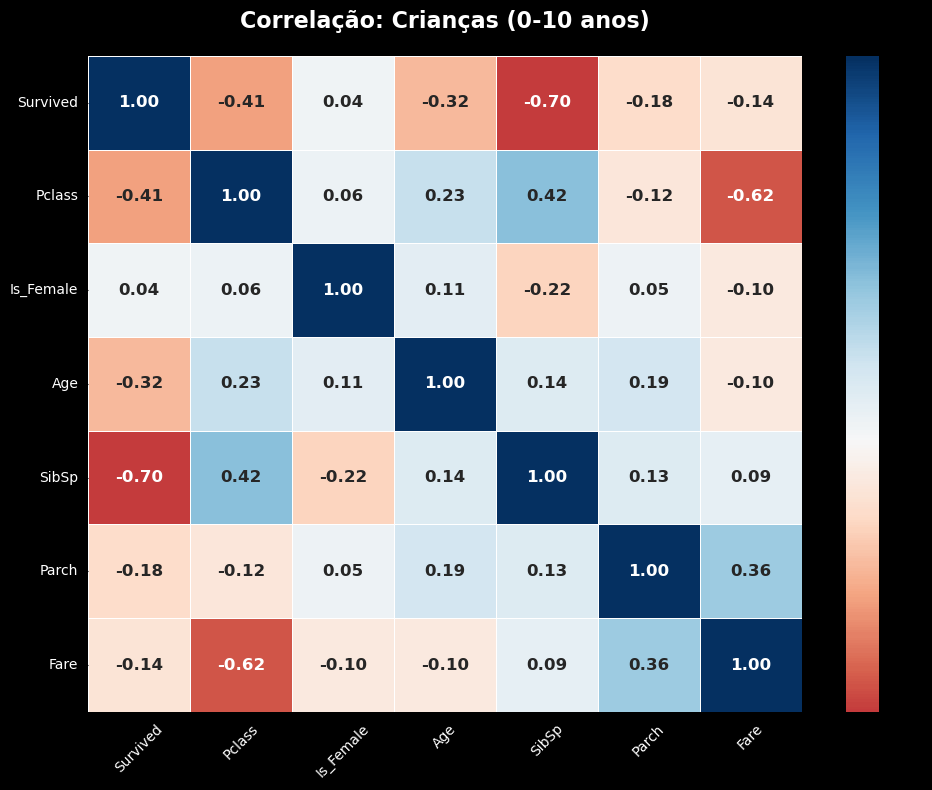

In [39]:
# 1. Filtro e Seleção
df_criancas = df[(df['Age'] >= 0) & (df['Age'] <= 10)].copy()
colunas_analise = ['Survived', 'Pclass', 'Is_Female', 'Age', 'SibSp', 'Parch', 'Fare']
corr_criancas = df_criancas[colunas_analise].corr()

# 2. Configuração Visual
plt.figure(figsize=(10, 8))
plt.rcParams.update({'figure.facecolor': 'black', 'axes.facecolor': 'black'})

# 3. Gerando o Heatmap com labels visíveis
sns.heatmap(corr_criancas, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu', 
            center=0, 
            linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"})

# Título e ajustes dos eixos (Labels)
plt.title('Correlação: Crianças (0-10 anos)', fontsize=16, fontweight='bold', color='white', pad=20)
plt.xticks(ticks=np.arange(len(colunas_analise))+0.5, labels=colunas_analise, color='white', rotation=45)
plt.yticks(ticks=np.arange(len(colunas_analise))+0.5, labels=colunas_analise, color='white', rotation=0)

plt.tight_layout() # Garante que os nomes das colunas não sejam cortados
plt.show()

#### 6.3 Matriz de Correlação: Adultos (20 a 40 anos)
Para o grupo de adultos, a dinâmica muda completamente. Aqui, o gênero retoma o papel central como principal preditor de sobrevivência.

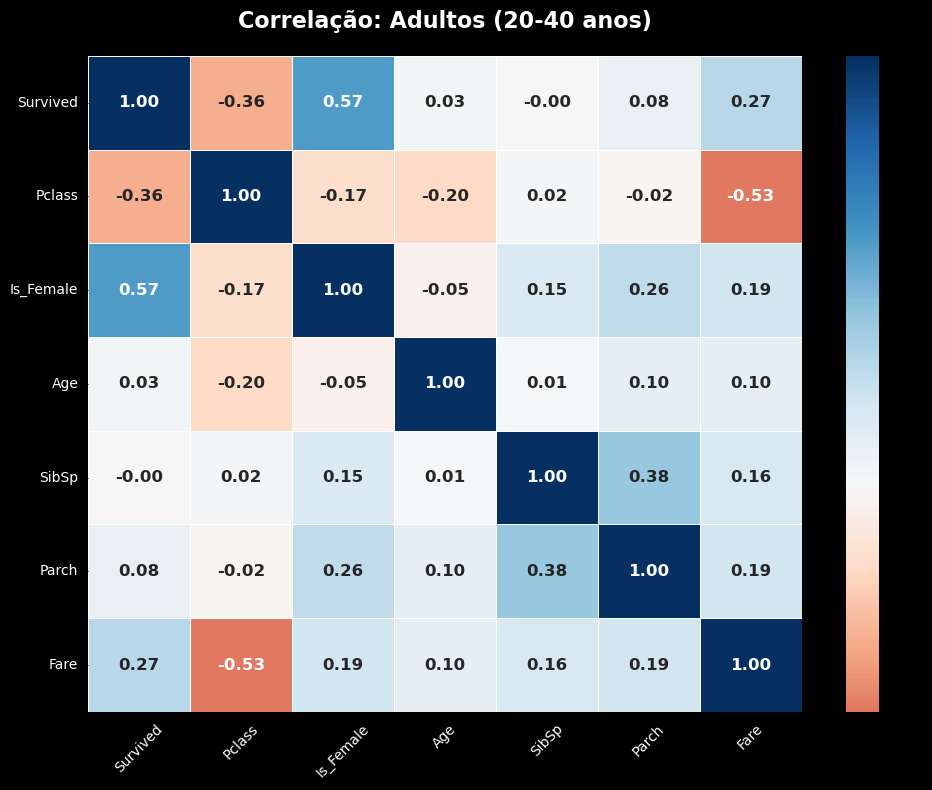

In [40]:
# 1. Filtro e Seleção
df_adultos = df[(df['Age'] >= 20) & (df['Age'] <= 40)].copy()
corr_adultos = df_adultos[colunas_analise].corr()

# 2. Configuração Visual
plt.figure(figsize=(10, 8))

# 3. Gerando o Heatmap
sns.heatmap(corr_adultos, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu', 
            center=0, 
            linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"})

# Título e ajustes dos eixos (Labels)
plt.title('Correlação: Adultos (20-40 anos)', fontsize=16, fontweight='bold', color='white', pad=20)
plt.xticks(ticks=np.arange(len(colunas_analise))+0.5, labels=colunas_analise, color='white', rotation=45)
plt.yticks(ticks=np.arange(len(colunas_analise))+0.5, labels=colunas_analise, color='white', rotation=0)

plt.tight_layout()
plt.show()

### 7. Comparação por Classe Social
Nesta seção, analisamos como a desigualdade econômica influenciou as chances de sobrevivência e como os fatores determinantes mudam quando comparamos a classe popular (3ª classe) com a elite (1ª e 2ª classes).

#### 7.1 Distribuição Absoluta de Sobrevivência por Classe
Primeiro, visualizamos o volume de passageiros sobreviventes em cada classe para entender o impacto direto do status socioeconômico.

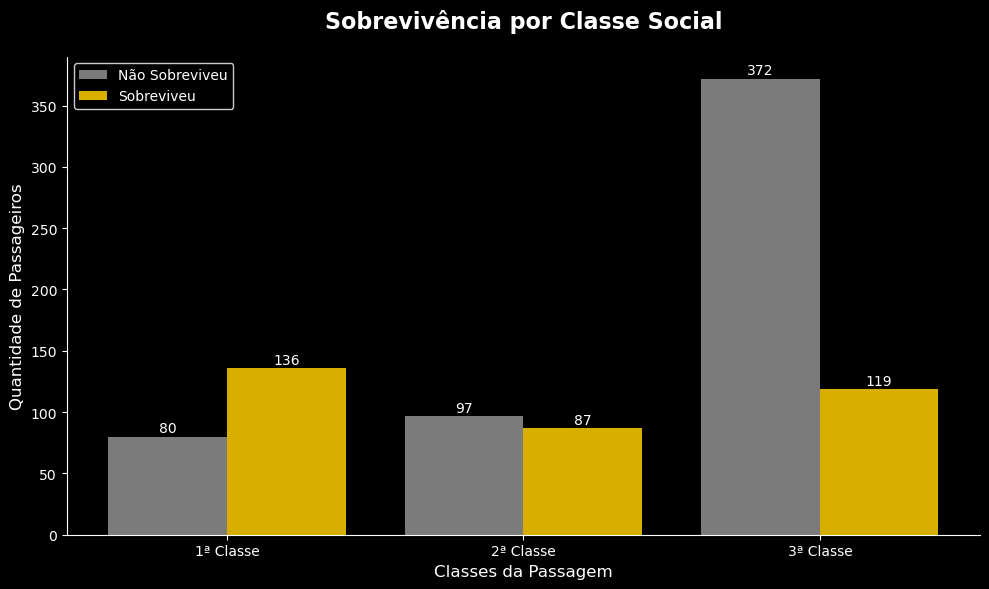

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dados e Agrupamento
sobrevivencia_classe = df.groupby(['Pclass', 'Survived']).size().unstack()
labels = ['1ª Classe', '2ª Classe', '3ª Classe']
x = np.arange(len(labels))
width = 0.4

# 2. Criação do Gráfico
fig, ax = plt.subplots(figsize=(10, 6), facecolor='black')
ax.set_facecolor('black')

# Barras
rects1 = ax.bar(x - width/2, sobrevivencia_classe[0], width, label='Não Sobreviveu', color='#7b7b7b')
rects2 = ax.bar(x + width/2, sobrevivencia_classe[1], width, label='Sobreviveu', color='#d8ae00')

# 3. Eixos e Títulos (Configuração Essencial)
ax.set_title('Sobrevivência por Classe Social', fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_ylabel('Quantidade de Passageiros', fontsize=12, color='white')
ax.set_xlabel('Classes da Passagem', fontsize=12, color='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, color='white')
ax.tick_params(axis='y', colors='white')

# Bordas dos eixos visíveis
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.legend(facecolor='black', edgecolor='white', labelcolor='white')

# Rótulos numéricos nas barras
for r in [rects1, rects2]:
    for rect in r:
        height = rect.get_height()
        ax.annotate(f'{int(height)}', xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', color='white')

plt.tight_layout()
plt.show()

#### 7.2 Correlação na Classe 3 (População Geral)
Analisamos passageiros adultos (20-40 anos) exclusivamente da 3ª classe.

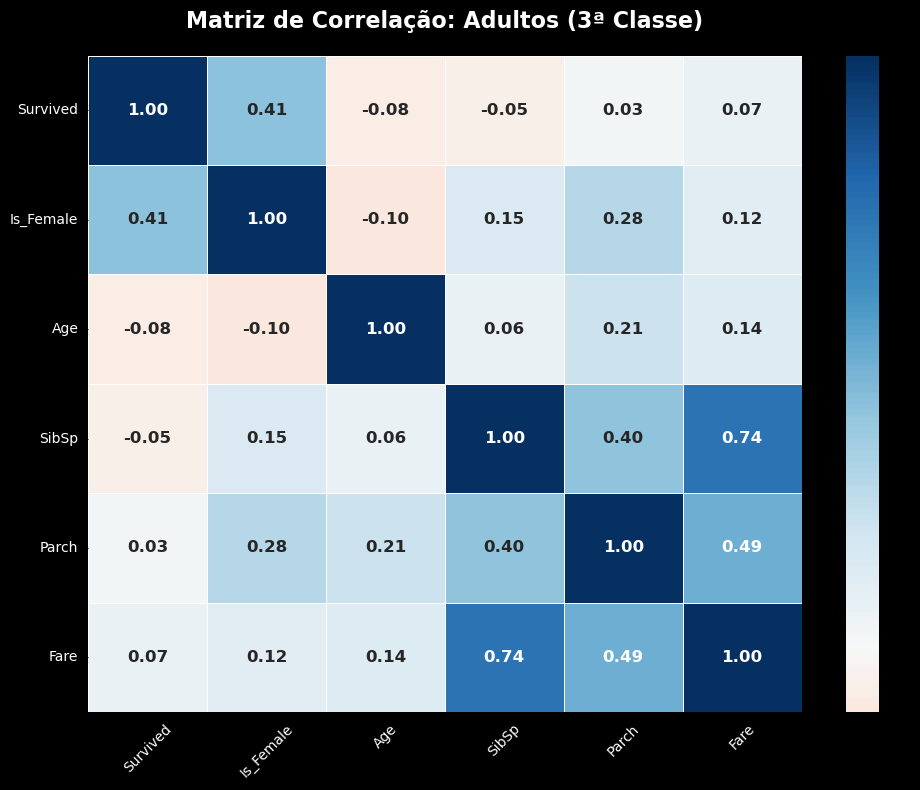

In [43]:
# 1. Filtro: Adultos da 3ª Classe
df_pobre = df[(df['Pclass'] == 3) & (df['Age'] >= 20) & (df['Age'] <= 40)].copy()

# 2. Matriz de Correlação
colunas_analise = ['Survived', 'Is_Female', 'Age', 'SibSp', 'Parch', 'Fare']
corr_pobre = df_pobre[colunas_analise].corr()

# 3. Visualização do Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pobre, annot=True, fmt=".2f", cmap='RdBu', center=0, linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Matriz de Correlação: Adultos (3ª Classe)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(color='white', rotation=45)
plt.yticks(color='white', rotation=0)
plt.tight_layout()
plt.show()

#### 7.3 Correlação nas Classes 1 e 2 (Elite)
Para efeito de comparação, analisamos o mesmo grupo etário nas classes superiores.

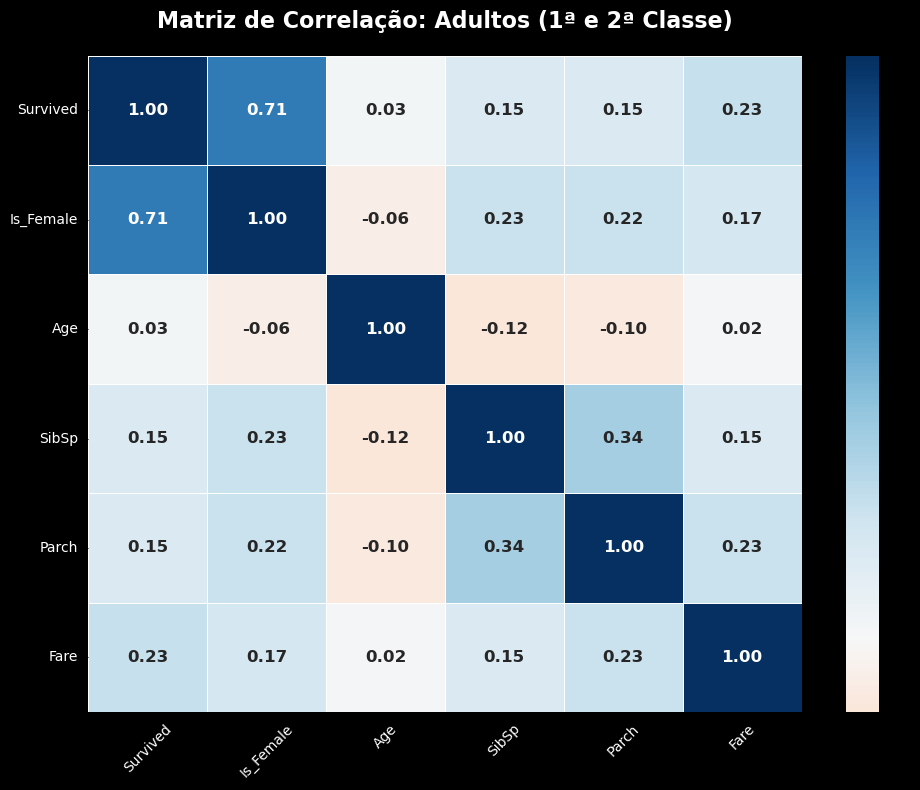

In [44]:
# 1. Filtro: Adultos da Elite (Classe 1 e 2)
df_elite = df[(df['Pclass'] != 3) & (df['Age'] >= 20) & (df['Age'] <= 40)].copy()

# 2. Matriz de Correlação
corr_elite = df_elite[colunas_analise].corr()

# 3. Visualização do Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_elite, annot=True, fmt=".2f", cmap='RdBu', center=0, linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Matriz de Correlação: Adultos (1ª e 2ª Classe)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(color='white', rotation=45)
plt.yticks(color='white', rotation=0)
plt.tight_layout()
plt.show()

### 8. Conclusão da Pesquisa
Com base nos dados analisados ao longo deste projeto, as principais conclusões são:

* **Gênero:** Confirmou-se como o fator mais decisivo para a sobrevivência de adultos, validando a aplicação rigorosa do protocolo de salvamento.
* **Idade:** Afeta a probabilidade de sobrevivência de forma seletiva. A idade não teve um impacto linear para todos, mas garantiu prioridade absoluta para o grupo infantil (especialmente bebês).
* **Logística Familiar:** Ter muitos irmãos ou parentes a bordo (`SibSp` / `Parch`) revelou-se um fator de risco crítico para crianças, especialmente na **3ª Classe**, sugerindo que a dificuldade de locomoção de grandes grupos familiares impediu o acesso oportuno aos botes.